# Downstream volatility forecasting

This notebook connects synthetic returns to a downstream forecast. Vol and return share the same scale-free features and the same random forest; only the target changes. Training mixes real and synthetic rows; evaluation always uses a held-out real test set.

Two synthetic sources are compared, with the same real data, mix grid, and test split:

- **hmm-diffusion**: specialist pools stitched along the supervised HMM state path on the 2014+ benchmark.
- **uncondi-diffusion**: windows from `trained_diffusion_withoutregime/generated_data.csv`, no HMM and no date alignment.

The mix grid is 0% through 90% synthetic (100% is omitted). Comparison plots use horizons **h = 1, 2, 3** and put hmm-diffusion and uncondi-diffusion on the same y-axis.

Run scripts 01 and 04 first, and install ta from requirements.txt. The HMM arm fits the supervised HMM only.



In [2]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

REPO_ROOT = Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

from hmmdiff.config import bootstrap_imports, config_path, load_config
from hmmdiff import data, models, plots, pools, stitch
import importlib

importlib.reload(plots)
from hmmdiff.downstream import (
    FEATURE_COLS,
    RETURN_FEATURE_COLS,
    RETURN_TARGET_COL,
    RF_KWARGS,
    VOL_FEATURE_COLS,
    VOL_TARGET_COL,
    build_advanced_vol_features,
    build_aligned_downstream_synth,
    build_uncond_synth_price_frame,
    compute_returns,
    load_real_benchmark,
    train_model_and_evaluate_advanced_return_mixture,
    train_model_and_evaluate_advanced_volatility_mixture,
)
from hmmdiff.mvo import load_uncond_windows
from hmmdiff.regimes import load_labels

bootstrap_imports()
warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_context("notebook")

cfg = load_config()
N_REGIMES = int(cfg["regimes"]["n_regimes"])
TOP_K = int(cfg["hmm"]["top_k"])
PRICE_COL = cfg["data"]["price_column"]
TEST_START_YEAR = "2014"
HORIZONS = [1, 2, 3]
MIX_GRID = list(range(0, 91, 10))
RANDOM_STATE = 42
UNCOND_CSV = REPO_ROOT / "trained_diffusion_withoutregime" / "generated_data.csv"
PLOT_ROOT = REPO_ROOT / "plots" / "downstream"

## Build the synthetic price path

Load diffusion pools with global z-score and per-regime calibration. Fit the supervised HMM on 2001–2014. Estimate 2014+ regimes from real z-scored returns with the full-sample smoother, stitch pool draws along that path, and integrate into prices anchored at the real benchmark start.


In [3]:
returns = data.load_returns(cfg)
labels = load_labels(config_path(cfg, "regime_labels"))
train_data, val_data = data.build_model_frames(returns, labels.labels, cfg)
val_regimes = val_data.regime.to_numpy(dtype=int)

pools_root = config_path(cfg, "pools")
using_placeholder = not pools.pools_available(pools_root, N_REGIMES)
GENERATED_TITLE = (
    "PLACEHOLDER: Resampled Real Returns (not diffusion)"
    if using_placeholder
    else "HMM Diffusion Generated Returns"
)
if using_placeholder:
    print("WARNING: using placeholder pools (resampled real returns)")
    generated_images = pools.placeholder_pools(
        train_data.emission.values,
        train_data.regime.values,
        N_REGIMES,
        size=len(train_data),
        seed=0,
    )
else:
    regime_stats = pools.regime_emission_stats(
        train_data.emission.values, train_data.regime.values, N_REGIMES
    )
    generated_images = pools.load_generated_images(
        pools_root,
        N_REGIMES,
        returns=returns,
        calibrate_regimes=regime_stats,
    )

init_dist = models.initial_distribution(train_data, N_REGIMES)
supervised = models.fit_supervised_hmm(train_data, N_REGIMES, cfg)

df_real = load_real_benchmark(cfg, test_start_year=TEST_START_YEAR, price_col=PRICE_COL)
aligned = build_aligned_downstream_synth(
    returns=returns,
    generated_images=generated_images,
    supervised=supervised,
    init_dist=init_dist,
    n_regimes=N_REGIMES,
    df_real=df_real,
    price_col=PRICE_COL,
    state_method="smooth",
)
df_synth = aligned.df_synth

common = df_real.index.intersection(df_synth.index)
df_real = df_real.loc[common]
df_synth = df_synth.loc[common]
benchmark = aligned

start_price = float(df_synth[PRICE_COL].iloc[0])
print(
    f"Aligned synthetic: {df_synth.index.min().date()} → {df_synth.index.max().date()} "
    f"({len(df_synth):,} trading days), start_price={start_price:,.2f}"
)
print(f"HMM fit on train: {len(train_data):,} days (2001–2014)")

100%|██████████| 2258/2258 [00:00<00:00, 97297.44it/s]
2258it [00:00, 57986.36it/s]

Aligned synthetic: 2014-01-06 → 2022-08-31 (2,258 trading days), start_price=7,091.52
HMM fit on train: 3,395 days (2001–2014)


In [4]:
real_returns_log = compute_returns(df_real, log=True, col=PRICE_COL)
synth_returns_log = compute_returns(df_synth, log=True, col=PRICE_COL)

print(
    f"Real benchmark panel: {df_real.index.min().date()} → {df_real.index.max().date()} "
    f"({len(df_real):,} trading days)"
)
display(df_real[[PRICE_COL, f"{PRICE_COL}_log"]].head())
display(df_synth[[PRICE_COL, f"{PRICE_COL}_log"]].head())

Real benchmark panel: 2014-01-06 → 2022-08-31 (2,258 trading days)


,A001,A001_log
2014-01-06,7091.52,8.866655
2014-01-07,7134.73,8.872730
2014-01-08,7135.35,8.872817
2014-01-09,7137.80,8.873160
2014-01-10,7154.29,8.875467


,A001,A001_log
2014-01-06,7091.520000,8.866655
2014-01-07,7101.749273,8.868096
2014-01-08,6900.880905,8.839404
2014-01-09,6891.798240,8.838087
2014-01-10,7047.262526,8.860395


## HMM stitch diagnostics

Same figures as HMM-Diffusion.ipynb for the supervised variant on train (2001–2014) and test (2014–2022).


Supervised HMM
Posterior transition matrix


to,0,1,2,3,4
from,,,,,
0,0.997,0.001,0.001,0.000,0.000
1,0.003,0.995,0.000,0.001,0.001
2,0.008,0.008,0.981,0.001,0.001
3,0.001,0.012,0.001,0.985,0.001
4,0.004,0.002,0.003,0.016,0.975


Emission parameters


,mean,sigma
regime,,
0,0.027441,0.595217
1,-0.027882,1.041095
2,-0.023610,1.616820
3,-0.074885,1.891646
4,-0.389891,3.646589


100%|██████████| 3395/3395 [00:00<00:00, 52059.25it/s]
3395it [00:00, 88691.35it/s]
100%|██████████| 2258/2258 [00:00<00:00, 59435.06it/s]
2258it [00:00, 52510.19it/s]


Train accuracy  94.79%   top-2  98.65%
Test  accuracy  72.85%   top-2  94.38%


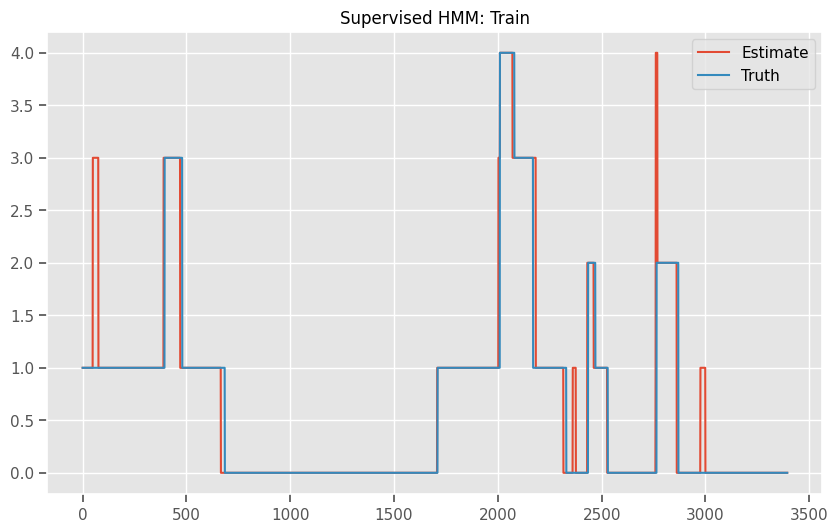

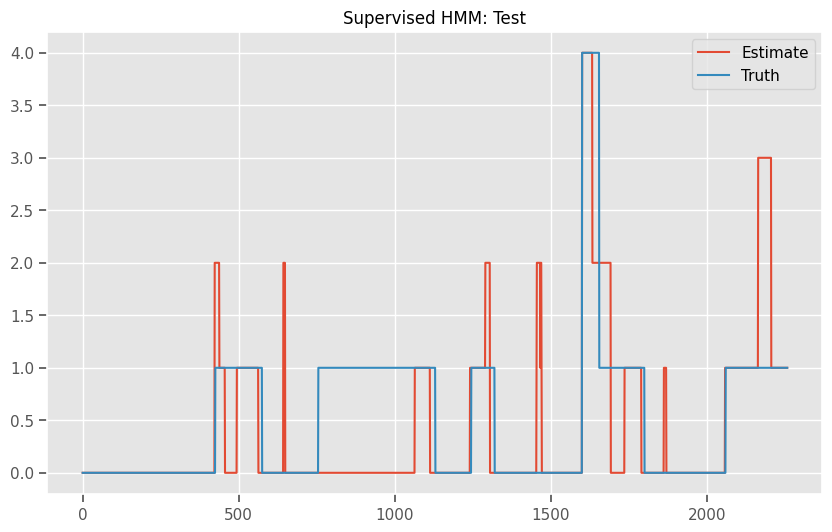

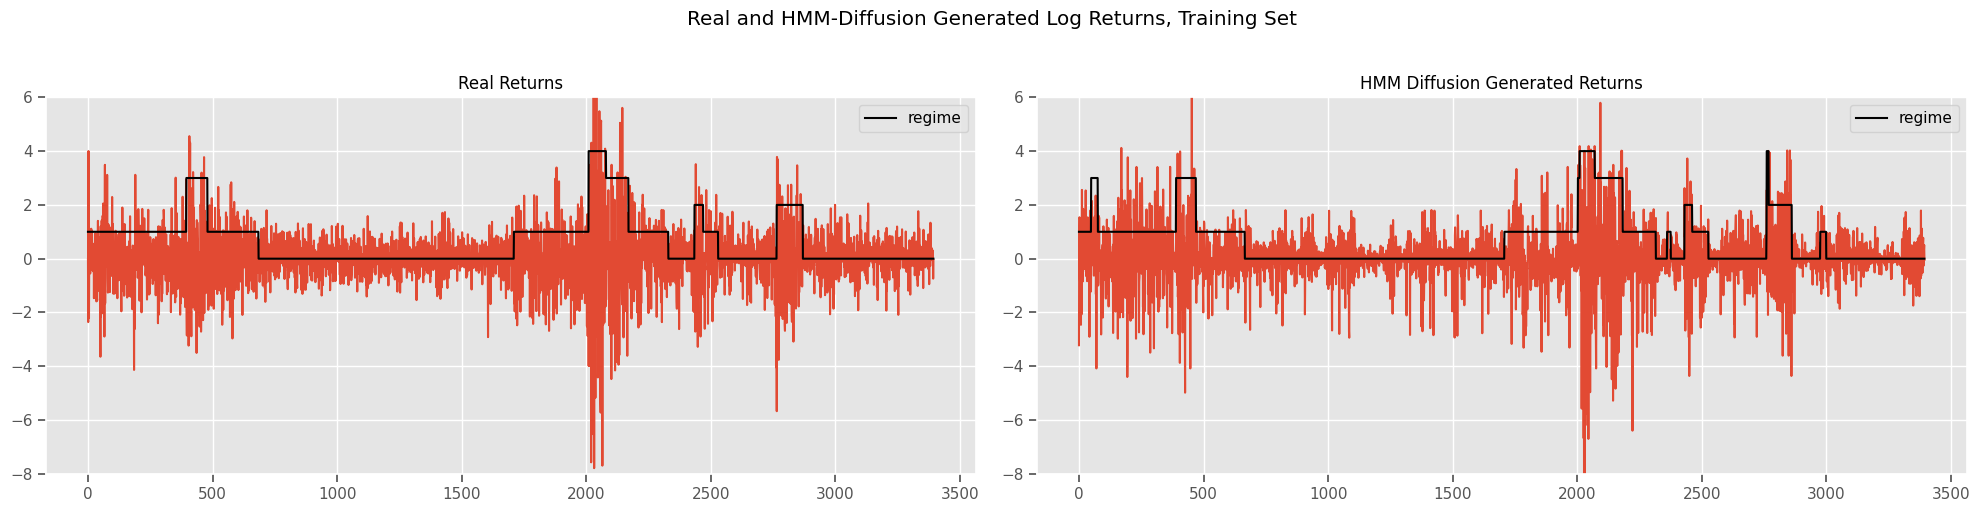

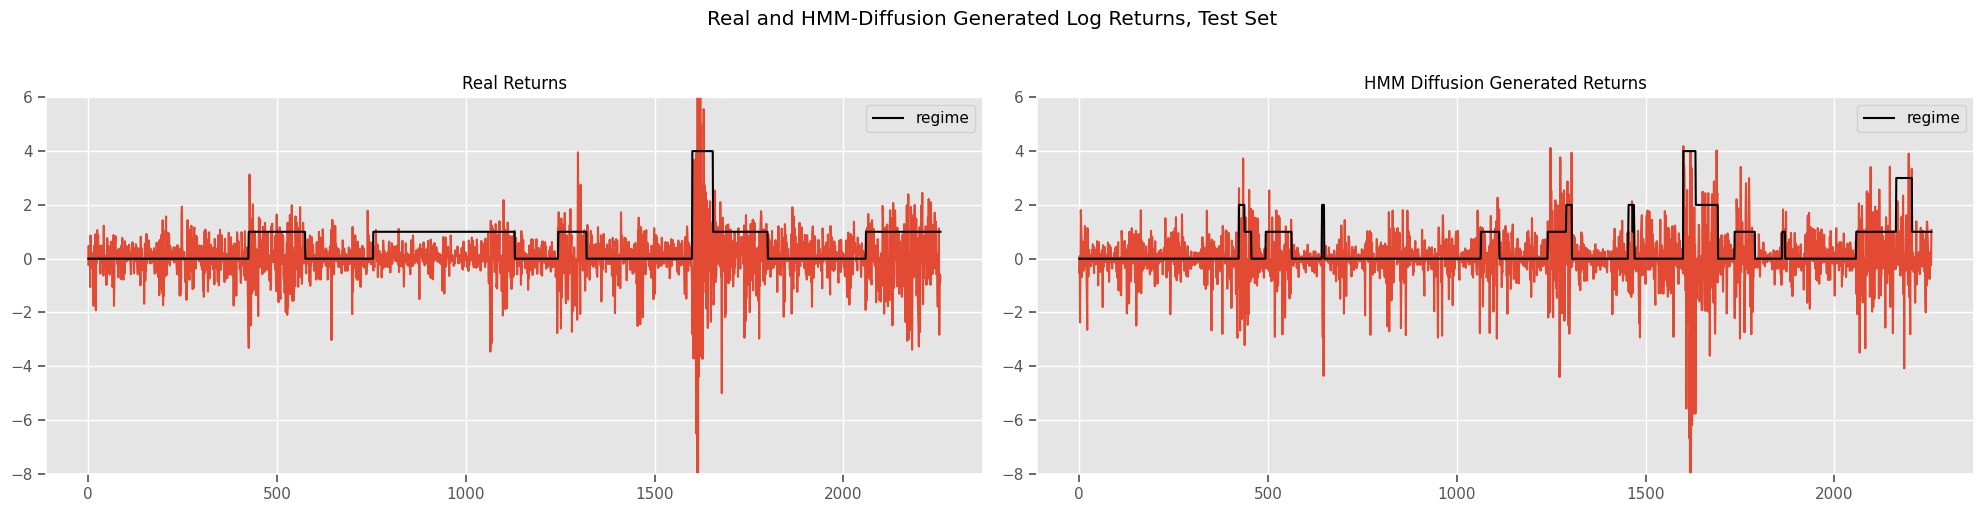

Train backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1890,0.025799,0.025412,0.353214,0.382592
1,1120,-0.028025,0.035249,1.084877,1.263453
2,140,-0.021750,0.019678,2.585972,2.775906
3,175,-0.070057,0.027656,3.559785,3.984950
4,70,-0.416327,-0.641971,13.000208,12.418782


Test backtest


,n,real_mean,gen_mean,real_var,gen_var
regime,,,,,
0,1260,0.026195,0.009479,0.353879,0.415995
1,943,0.005973,0.064767,0.845995,1.146122
2,0,NaN,NaN,NaN,NaN
3,0,NaN,NaN,NaN,NaN
4,55,-0.210249,-0.888796,11.739773,11.136981


In [5]:
index = pd.Index(range(N_REGIMES), name="from")
columns = pd.Index(range(N_REGIMES), name="to")

print("=" * 78)
print(supervised.name)
print("=" * 78)
print("Posterior transition matrix")
display(pd.DataFrame(supervised.transmat.round(3), index=index, columns=columns))
print("Emission parameters")
display(supervised.summary())

train_probs, train_est = models.estimate_states(
    supervised, train_data.emission.values, init_dist, N_REGIMES
)
val_probs, val_est = models.estimate_states(
    supervised, val_data.emission.values, init_dist, N_REGIMES
)
train_acc = models.accuracy_report(
    train_data.regime.values, train_est, train_probs, N_REGIMES, TOP_K
)
val_acc = models.accuracy_report(val_regimes, val_est, val_probs, N_REGIMES, TOP_K)

print(
    f"Train accuracy {train_acc['accuracy']:>7.2%}   "
    f"top-{TOP_K} {train_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
)
print(
    f"Test  accuracy {val_acc['accuracy']:>7.2%}   "
    f"top-{TOP_K} {val_acc[f'top_{TOP_K}_accuracy']:>7.2%}"
)

plots.plot_estimates(train_est, train_data.regime.values, f"{supervised.name}: Train")
plots.plot_estimates(val_est, val_regimes, f"{supervised.name}: Test")

train_generated, val_generated = plots.plot_paper_train_test(
    train_data.emission.values,
    train_data.regime.values,
    train_est,
    val_data.emission.values,
    val_regimes,
    val_est,
    generated_images,
    generated_title=GENERATED_TITLE,
)

train_table = stitch.backtest_table(
    train_data.emission.values,
    train_data.regime.values,
    train_generated,
    train_est,
    N_REGIMES,
)
val_table = stitch.backtest_table(
    val_data.emission.values,
    val_regimes,
    val_generated,
    val_est,
    N_REGIMES,
)
print("Train backtest")
display(train_table)
print("Test backtest")
display(val_table)

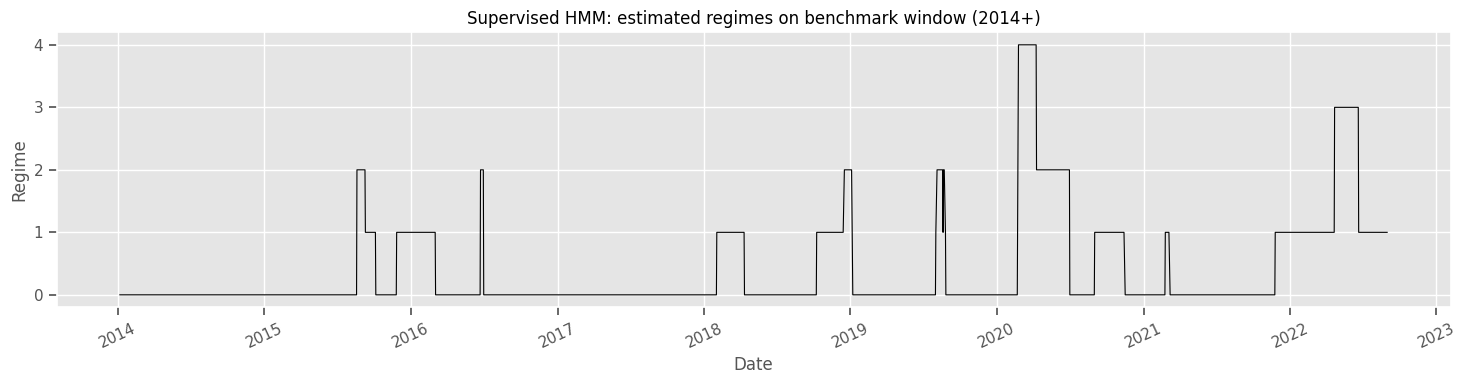

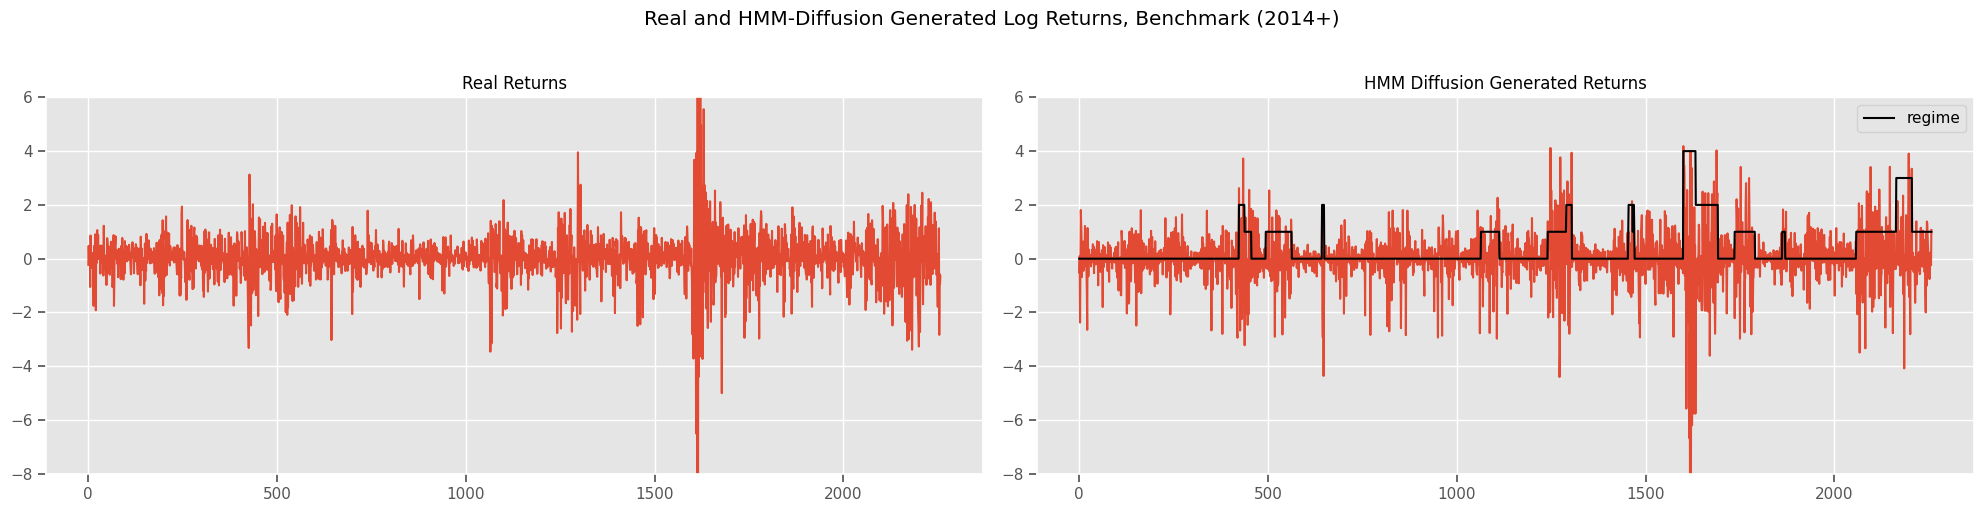

Per-regime moments on benchmark window (estimated regime path)


real                      generated                     
       n_days      mean   variance    n_days      mean   variance
regime                                                           
0        1666  0.048771   0.267617      1666  0.021711   0.390161
1         408 -0.052800   1.158888       408  0.040476   1.480408
2         109 -0.008214   2.319018       109  0.004343   2.649661
3          42 -0.365414   2.551293        42  0.406956   2.046741
4          33 -0.496747  17.644726        33 -1.397459  16.686363

In [6]:
fig, ax = plt.subplots(figsize=(15, 4))
ax.plot(benchmark.dates, benchmark.regime_est, color="black", lw=0.8)
ax.set_title(f"Supervised HMM: estimated regimes on benchmark window ({TEST_START_YEAR}+)")
ax.set_xlabel("Date")
ax.set_ylabel("Regime")
ax.tick_params(axis="x", rotation=25)
fig.tight_layout()
plt.show()

plots.plot_real_vs_generated(
    benchmark.emissions,
    None,
    benchmark.stitched_z,
    benchmark.regime_est,
    generated_title=GENERATED_TITLE,
    suptitle=f"Real and HMM-Diffusion Generated Log Returns, Benchmark ({TEST_START_YEAR}+)",
)

print("Per-regime moments on benchmark window (estimated regime path)")
display(
    pd.concat(
        {
            "real": plots.regime_moments(benchmark.emissions, benchmark.regime_est, N_REGIMES),
            "generated": plots.regime_moments(benchmark.stitched_z, benchmark.regime_est, N_REGIMES),
        },
        axis=1,
    )
)

## Real vs synthetic sanity checks

Both series cover the same 2014+ trading days. The synthetic path is anchored to the real benchmark price on the first shared date. The downstream experiment uses log-price changes, not absolute levels.


Synthetic: 2014-01-06 → 2022-08-31, start price 7,091.52
Real: 2014-01-06 → 2022-08-31, start price 7,091.52


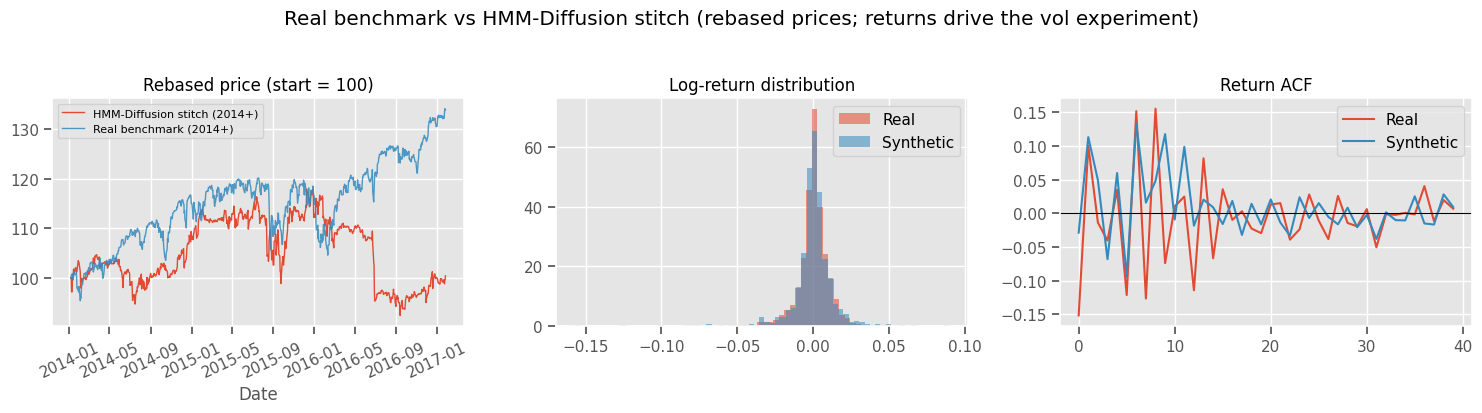

In [7]:
def rebase_to_100(prices: np.ndarray) -> np.ndarray:
    prices = np.asarray(prices, dtype=float)
    return 100.0 * prices / prices[0]


plot_dates = df_real.index[: min(800, len(df_real))]
synth_rebased = rebase_to_100(df_synth.loc[plot_dates, PRICE_COL].values)
real_rebased = rebase_to_100(df_real.loc[plot_dates, PRICE_COL].values)

print(
    f"Synthetic: {df_synth.index.min().date()} → {df_synth.index.max().date()}, "
    f"start price {df_synth[PRICE_COL].iloc[0]:,.2f}"
)
print(
    f"Real: {df_real.index.min().date()} → {df_real.index.max().date()}, "
    f"start price {df_real[PRICE_COL].iloc[0]:,.2f}"
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(plot_dates, synth_rebased, label="HMM-Diffusion stitch (2014+)", lw=1)
axes[0].plot(plot_dates, real_rebased, label=f"Real benchmark ({TEST_START_YEAR}+)", lw=1, alpha=0.85)
axes[0].set_title("Rebased price (start = 100)")
axes[0].set_xlabel("Date")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=25)

axes[1].hist(real_returns_log.values, bins=60, density=True, alpha=0.55, label="Real")
axes[1].hist(synth_returns_log.values, bins=60, density=True, alpha=0.55, label="Synthetic")
axes[1].set_title("Log-return distribution")
axes[1].legend()

max_lag = 40

def acf(x, nlags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[:-lag], x[lag:]) / denom for lag in range(1, nlags + 1)])

axes[2].plot(acf(real_returns_log.values, max_lag), label="Real")
axes[2].plot(acf(synth_returns_log.values, max_lag), label="Synthetic")
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Return ACF")
axes[2].legend()

fig.suptitle(
    "Real benchmark vs HMM-Diffusion stitch (rebased prices; returns drive the vol experiment)",
    y=1.03,
)
fig.tight_layout()
plt.show()

## Volatility mixture experiment (hmm-diffusion)

A random forest predicts 21-day realized volatility **1 day ahead**. Vol and return use the **same scale-free inputs** and the **same forest** (`n_estimators=200`, `min_samples_leaf=20`, `max_depth=8`). Inputs are HAR vol (windows, log vol, vol-of-vol, quarticity, lags), lagged returns, and price-normalized TA. Synthetic rows come from the HMM-stitched 2014+ path. Training sweeps the synthetic share from 0% to 90%. The test set is always the last 20% of real rows.



In [8]:
price_col = PRICE_COL
assert FEATURE_COLS == VOL_FEATURE_COLS == RETURN_FEATURE_COLS
feature_spec = pd.DataFrame(
    [
        ("Returns", "input", "1-day simple return"),
        ("Ret_5", "input", "5-day simple return"),
        ("Ret_10", "input", "10-day simple return"),
        ("Ret_21", "input", "21-day simple return"),
        ("AbsRet", "input", "absolute 1-day return"),
        ("Vol_5", "input", "5-day rolling std of returns, annualized (√252)"),
        ("Volatility", "input", "21-day rolling std of returns, annualized (√252)"),
        ("Vol_63", "input", "63-day rolling std of returns, annualized (√252)"),
        ("LogVol", "input", "log of 21-day vol (HAR-log)"),
        ("Vol_of_Vol", "input", "21-day rolling std of 21-day vol"),
        ("Vol_21_lag5", "input", "21-day vol lagged 5 days"),
        ("Vol_21_lag21", "input", "21-day vol lagged 21 days"),
        ("AbsRet_5", "input", "5-day mean absolute return"),
        ("AbsRet_21", "input", "21-day mean absolute return"),
        ("RQ_21", "input", "21-day realized quarticity (mean of r⁴)"),
        ("MA_ratio_21", "input", "price / 21-day MA − 1"),
        ("RSI", "input", "14-day RSI of price"),
        ("MACD_norm", "input", "MACD histogram / price (fast=12, slow=26, signal=9)"),
        ("BB_pct", "input", "21-day Bollinger %B"),
        ("Ret_x_Vol", "input", "1-day return × 21-day vol (leverage)"),
        ("Ret_skew_21", "input", "21-day rolling skew of returns"),
        ("Ret_kurt_21", "input", "21-day rolling kurtosis of returns"),
        (
            VOL_TARGET_COL,
            "output (vol)",
            "same 21-day Volatility, horizon trading days after the feature date t",
        ),
        (
            RETURN_TARGET_COL,
            "output (return)",
            "simple return from t to t+horizon, P_{t+h}/P_t − 1",
        ),
    ],
    columns=["feature", "role", "definition"],
)
print(
    f"price series {price_col}  panel {df_real.index.min().date()} → {df_real.index.max().date()}  "
    f"({len(df_real):,} days)"
)
print(f"shared forest {RF_KWARGS}")
print(f"model inputs {list(FEATURE_COLS)}  output vol={VOL_TARGET_COL}  return={RETURN_TARGET_COL}")

date_rows = []
for horizon in HORIZONS:
    feat = build_advanced_vol_features(
        df_real, price_col=price_col, intraday=False, horizon=horizon
    )
    split_idx = int(0.8 * len(feat))
    train, test = feat.iloc[:split_idx], feat.iloc[split_idx:]
    target = pd.to_datetime(feat["target_date"])
    date_rows.append(
        {
            "horizon": horizon,
            "n_rows": len(feat),
            "feature t": f"{feat.index.min().date()} → {feat.index.max().date()}",
            "target date": f"{target.min().date()} → {target.max().date()}",
            "train t (80%)": f"{train.index.min().date()} → {train.index.max().date()} ({len(train)})",
            "test t (20%)": f"{test.index.min().date()} → {test.index.max().date()} ({len(test)})",
        }
    )
dates = pd.DataFrame(date_rows)

def _show_full(frame: pd.DataFrame) -> None:
    display(
        frame.style.hide(axis="index")
        .set_properties(**{"text-align": "left", "white-space": "pre-wrap"})
        .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}])
    )

_show_full(feature_spec)
_show_full(dates)
print(
    "Features are observed at date t. The target is 21-day vol on target date = t + horizon trading days."
)

price series A001  panel 2014-01-06 → 2022-08-31  (2,258 days)
shared forest {'n_estimators': 200, 'min_samples_leaf': 20, 'max_depth': 8}
model inputs ['Returns', 'Ret_5', 'Ret_10', 'Ret_21', 'AbsRet', 'Vol_5', 'Volatility', 'Vol_63', 'LogVol', 'Vol_of_Vol', 'Vol_21_lag5', 'Vol_21_lag21', 'AbsRet_5', 'AbsRet_21', 'RQ_21', 'MA_ratio_21', 'RSI', 'MACD_norm', 'BB_pct', 'Ret_x_Vol', 'Ret_skew_21', 'Ret_kurt_21']  output vol=Future_Volatility  return=Future_Return


feature,role,definition
Returns,input,1-day simple return
Ret_5,input,5-day simple return
Ret_10,input,10-day simple return
Ret_21,input,21-day simple return
AbsRet,input,absolute 1-day return
Vol_5,input,"5-day rolling std of returns, annualized (√252)"
Volatility,input,"21-day rolling std of returns, annualized (√252)"
Vol_63,input,"63-day rolling std of returns, annualized (√252)"
LogVol,input,log of 21-day vol (HAR-log)
Vol_of_Vol,input,21-day rolling std of 21-day vol


horizon,n_rows,feature t,target date,train t (80%),test t (20%)
1,2194,2014-04-03 → 2022-08-30,2014-04-04 → 2022-08-31,2014-04-03 → 2020-12-23 (1755),2020-12-24 → 2022-08-30 (439)
2,2193,2014-04-03 → 2022-08-29,2014-04-07 → 2022-08-31,2014-04-03 → 2020-12-22 (1754),2020-12-23 → 2022-08-29 (439)
3,2192,2014-04-03 → 2022-08-26,2014-04-08 → 2022-08-31,2014-04-03 → 2020-12-21 (1753),2020-12-22 → 2022-08-26 (439)


Features are observed at date t. The target is 21-day vol on target date = t + horizon trading days.


In [9]:
metrics_by_horizon = {}

for horizon in HORIZONS:
    print("=" * 72)
    print(f"Horizon = {horizon} day(s)")
    print("=" * 72)
    metrics_df = train_model_and_evaluate_advanced_volatility_mixture(
        df_real=df_real,
        df_synth=df_synth,
        is_intraday=False,
        price_col=PRICE_COL,
        horizon=horizon,
        show_each_pred_plot=False,
        mix_grid=MIX_GRID,
        random_state=RANDOM_STATE,
        plot_summary=False,
        synth_source="hmm-diffusion",
    )
    metrics_df["horizon"] = horizon
    metrics_by_horizon[horizon] = metrics_df

all_metrics = pd.concat(metrics_by_horizon.values(), ignore_index=True)
all_metrics.head()

Horizon = 1 day(s)
mean baseline (predict train mean) | Test R2 = -0.132
               100 % Real | Test MSE = 0.000088 | R2 = +0.980
      9% Synth + 91% Real | Test MSE = 0.000082 | R2 = +0.982
     21% Synth + 79% Real | Test MSE = 0.000077 | R2 = +0.983
     32% Synth + 68% Real | Test MSE = 0.000085 | R2 = +0.981
     40% Synth + 60% Real | Test MSE = 0.000082 | R2 = +0.982
     49% Synth + 51% Real | Test MSE = 0.000081 | R2 = +0.982
     59% Synth + 41% Real | Test MSE = 0.000079 | R2 = +0.983
     70% Synth + 30% Real | Test MSE = 0.000083 | R2 = +0.982
     81% Synth + 19% Real | Test MSE = 0.000074 | R2 = +0.983
     90% Synth + 10% Real | Test MSE = 0.000080 | R2 = +0.982
Horizon = 2 day(s)
mean baseline (predict train mean) | Test R2 = -0.132
               100 % Real | Test MSE = 0.000174 | R2 = +0.961
      9% Synth + 91% Real | Test MSE = 0.000168 | R2 = +0.963
     21% Synth + 79% Real | Test MSE = 0.000154 | R2 = +0.966
     32% Synth + 68% Real | Test MSE = 0.000170 

,synthetic_pct,mse,r2,horizon
0,0,0.000088,0.980467,1
1,10,0.000082,0.981643,1
2,20,0.000077,0.982809,1
3,30,0.000085,0.981151,1
4,40,0.000082,0.981721,1


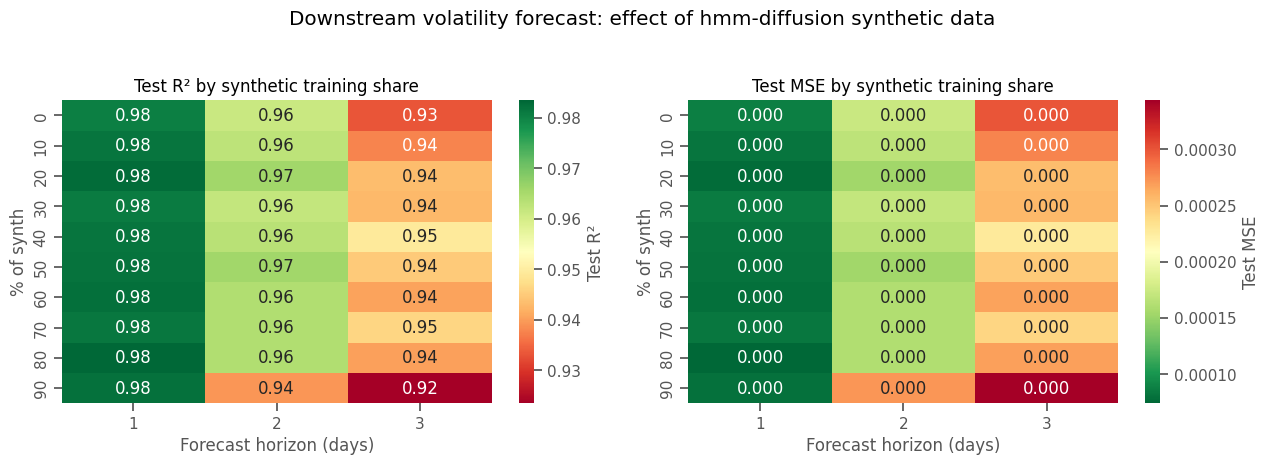

,r2_real_only,r2_best_mix,best_mix_pct
horizon,,,
1,0.980,0.983,80
2,0.961,0.966,50
3,0.933,0.949,40


In [10]:
hmm_plot = all_metrics.loc[all_metrics["synthetic_pct"] <= plots.VOL_MIX_PCT_MAX]
pivot_r2 = hmm_plot.pivot(index="synthetic_pct", columns="horizon", values="r2")
pivot_mse = hmm_plot.pivot(index="synthetic_pct", columns="horizon", values="mse")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pivot_r2, annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[0], cbar_kws={"label": "Test R²"})
axes[0].set_title("Test R² by synthetic training share")
axes[0].set_xlabel("Forecast horizon (days)")
axes[0].set_ylabel("% of synth")

sns.heatmap(pivot_mse, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=axes[1], cbar_kws={"label": "Test MSE"})
axes[1].set_title("Test MSE by synthetic training share")
axes[1].set_xlabel("Forecast horizon (days)")
axes[1].set_ylabel("% of synth")

fig.suptitle("Downstream volatility forecast: effect of hmm-diffusion synthetic data", y=1.03)
fig.tight_layout()
plt.show()

summary_rows = []
for horizon, frame in metrics_by_horizon.items():
    frame = frame.loc[frame["synthetic_pct"] <= plots.VOL_MIX_PCT_MAX]
    real_only = frame.loc[frame["synthetic_pct"] == 0].iloc[0]
    best = frame.loc[frame["r2"].idxmax()]
    summary_rows.append(
        {
            "horizon": horizon,
            "r2_real_only": real_only["r2"],
            "r2_best_mix": best["r2"],
            "best_mix_pct": int(best["synthetic_pct"]),
        }
    )

summary = pd.DataFrame(summary_rows).set_index("horizon")
display(summary.style.format({
    "r2_real_only": "{:.3f}",
    "r2_best_mix": "{:.3f}",
}))

## Volatility mixture experiment (uncondi-diffusion)

Same forest, features, mix grid, and real test split as above. Synthetic prices are built from `trained_diffusion_withoutregime/generated_data.csv` (1024 windows × 128 days × 10 assets, raw log returns). Only A001 is used. Windows are not date-matched and are not stitched with the HMM; a NaN row between windows keeps rolling TA features inside each 128-day sample.


In [11]:
uncond_windows = load_uncond_windows(UNCOND_CSV)
df_synth_uncond = build_uncond_synth_price_frame(
    uncond_windows,
    start_price=float(df_real[PRICE_COL].iloc[0]),
    price_col=PRICE_COL,
)
print(
    f"uncondi-diffusion windows {uncond_windows.shape}  "
    f"price rows {len(df_synth_uncond):,} "
    f"(including {int(df_synth_uncond[PRICE_COL].isna().sum())} window gaps)"
)
print("no calendar alignment; mix uses the same real test rows as the hmm-diffusion arm")

metrics_by_horizon_uncond = {}
for horizon in HORIZONS:
    print("=" * 72)
    print(f"Horizon = {horizon} day(s)  [uncondi-diffusion]")
    print("=" * 72)
    metrics_df = train_model_and_evaluate_advanced_volatility_mixture(
        df_real=df_real,
        df_synth=df_synth_uncond,
        is_intraday=False,
        price_col=PRICE_COL,
        horizon=horizon,
        show_each_pred_plot=False,
        mix_grid=MIX_GRID,
        random_state=RANDOM_STATE,
        plot_summary=False,
        synth_source="uncondi-diffusion",
    )
    metrics_df["horizon"] = horizon
    metrics_by_horizon_uncond[horizon] = metrics_df

all_metrics_uncond = pd.concat(metrics_by_horizon_uncond.values(), ignore_index=True)
all_metrics_uncond.head()


uncondi-diffusion windows (1024, 128, 10)  price rows 132,095 (including 1023 window gaps)
no calendar alignment; mix uses the same real test rows as the hmm-diffusion arm
Horizon = 1 day(s)  [uncondi-diffusion]
mean baseline (predict train mean) | Test R2 = -0.132
               100 % Real | Test MSE = 0.000088 | R2 = +0.980
      9% Synth + 91% Real | Test MSE = 0.000071 | R2 = +0.984
     21% Synth + 79% Real | Test MSE = 0.000075 | R2 = +0.983
     32% Synth + 68% Real | Test MSE = 0.000076 | R2 = +0.983
     40% Synth + 60% Real | Test MSE = 0.000075 | R2 = +0.983
     49% Synth + 51% Real | Test MSE = 0.000077 | R2 = +0.983
     59% Synth + 41% Real | Test MSE = 0.000077 | R2 = +0.983
     70% Synth + 30% Real | Test MSE = 0.000079 | R2 = +0.982
     81% Synth + 19% Real | Test MSE = 0.000081 | R2 = +0.982
     90% Synth + 10% Real | Test MSE = 0.000089 | R2 = +0.980
Horizon = 2 day(s)  [uncondi-diffusion]
mean baseline (predict train mean) | Test R2 = -0.132
               100 %

,synthetic_pct,mse,r2,horizon
0,0,0.000088,0.980467,1
1,10,0.000071,0.984149,1
2,20,0.000075,0.983232,1
3,30,0.000076,0.982990,1
4,40,0.000075,0.983241,1


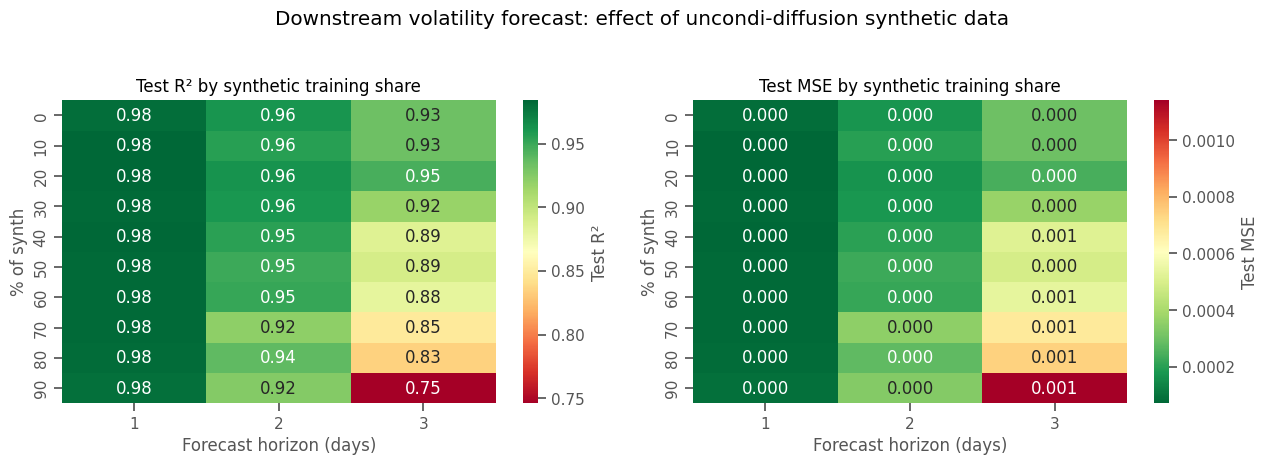

,r2_real_only,r2_best_mix,best_mix_pct
horizon,,,
1,0.980,0.984,10
2,0.961,0.962,20
3,0.933,0.946,20


In [12]:
uncond_plot = all_metrics_uncond.loc[all_metrics_uncond["synthetic_pct"] <= plots.VOL_MIX_PCT_MAX]
pivot_r2_uncond = uncond_plot.pivot(index="synthetic_pct", columns="horizon", values="r2")
pivot_mse_uncond = uncond_plot.pivot(index="synthetic_pct", columns="horizon", values="mse")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.heatmap(pivot_r2_uncond, annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[0], cbar_kws={"label": "Test R²"})
axes[0].set_title("Test R² by synthetic training share")
axes[0].set_xlabel("Forecast horizon (days)")
axes[0].set_ylabel("% of synth")

sns.heatmap(pivot_mse_uncond, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=axes[1], cbar_kws={"label": "Test MSE"})
axes[1].set_title("Test MSE by synthetic training share")
axes[1].set_xlabel("Forecast horizon (days)")
axes[1].set_ylabel("% of synth")

fig.suptitle("Downstream volatility forecast: effect of uncondi-diffusion synthetic data", y=1.03)
fig.tight_layout()
plt.show()

summary_rows_uncond = []
for horizon, frame in metrics_by_horizon_uncond.items():
    frame = frame.loc[frame["synthetic_pct"] <= plots.VOL_MIX_PCT_MAX]
    real_only = frame.loc[frame["synthetic_pct"] == 0].iloc[0]
    best = frame.loc[frame["r2"].idxmax()]
    summary_rows_uncond.append(
        {
            "horizon": horizon,
            "r2_real_only": real_only["r2"],
            "r2_best_mix": best["r2"],
            "best_mix_pct": int(best["synthetic_pct"]),
        }
    )

summary_uncond = pd.DataFrame(summary_rows_uncond).set_index("horizon")
display(summary_uncond.style.format({
    "r2_real_only": "{:.3f}",
    "r2_best_mix": "{:.3f}",
}))


## Return mixture experiment

Same features, forest, mix grid, real test split, and sources as the volatility section. Only the target changes: the simple return \(P_{t+1}/P_t - 1\) on raw prices.

Daily returns are close to unpredictable, so a large positive test R² is not expected. The shared forest (`min_samples_leaf=20`, `max_depth=8`) is a compromise: vol can still track overlapping 21-day RV, while returns stay closer to the mean baseline than an unregularized forest on price-level MA/MACD.

After both tasks finish, one 3×2 figure shows test R² by % of synth: rows are h = 1, 2, 3; left column is volatility; right column is return.

shared inputs ['Returns', 'Ret_5', 'Ret_10', 'Ret_21', 'AbsRet', 'Vol_5', 'Volatility', 'Vol_63', 'LogVol', 'Vol_of_Vol', 'Vol_21_lag5', 'Vol_21_lag21', 'AbsRet_5', 'AbsRet_21', 'RQ_21', 'MA_ratio_21', 'RSI', 'MACD_norm', 'BB_pct', 'Ret_x_Vol', 'Ret_skew_21', 'Ret_kurt_21']  output Future_Return
Horizon = 1 day(s)  [hmm-diffusion, return]
mean baseline (predict train mean) | Test R2 = -0.001
               100 % Real | Test MSE = 0.000130 | R2 = -0.037
      9% Synth + 91% Real | Test MSE = 0.000129 | R2 = -0.030
     21% Synth + 79% Real | Test MSE = 0.000130 | R2 = -0.039
     32% Synth + 68% Real | Test MSE = 0.000124 | R2 = +0.010
     40% Synth + 60% Real | Test MSE = 0.000129 | R2 = -0.032
     49% Synth + 51% Real | Test MSE = 0.000133 | R2 = -0.063
     59% Synth + 41% Real | Test MSE = 0.000129 | R2 = -0.032
     70% Synth + 30% Real | Test MSE = 0.000130 | R2 = -0.035
     81% Synth + 19% Real | Test MSE = 0.000128 | R2 = -0.025
     90% Synth + 10% Real | Test MSE = 0.000130

,synthetic_pct,mse,r2,horizon
0,0,0.000130,-0.037071,1
1,10,0.000129,-0.030211,1
2,20,0.000130,-0.038836,1
3,30,0.000124,0.009654,1
4,40,0.000129,-0.032481,1


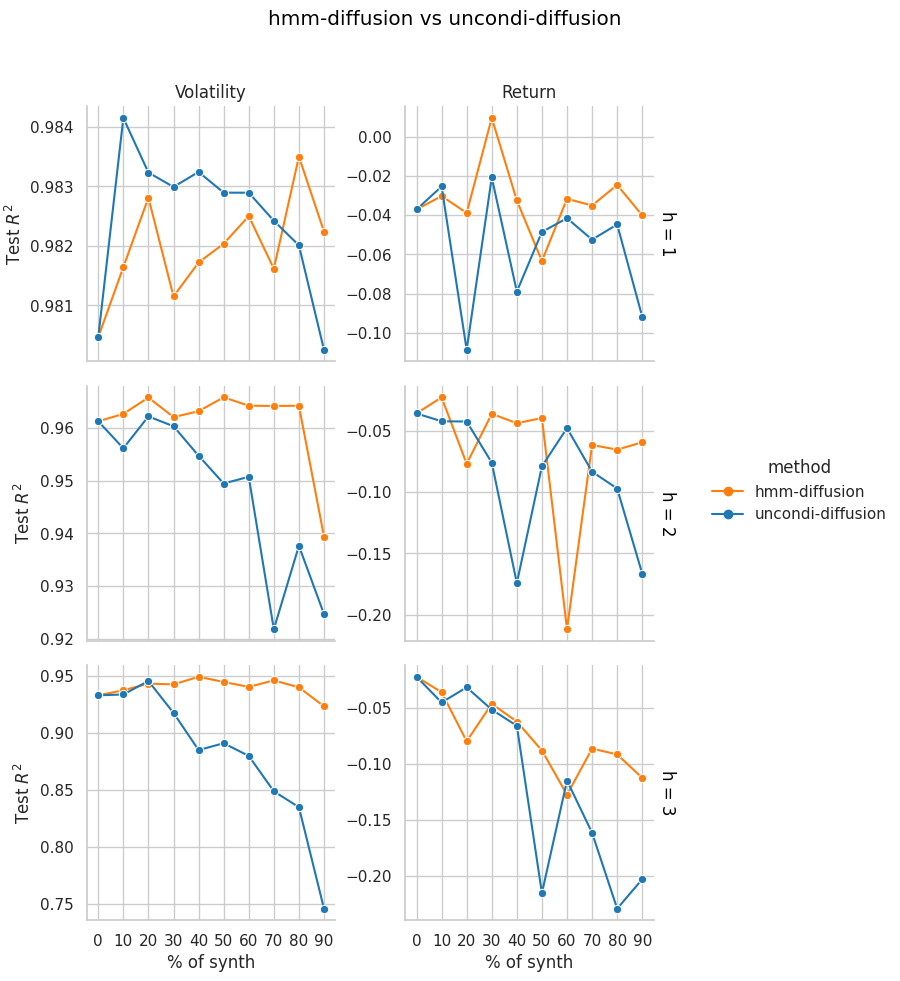

In [13]:
print(f"shared inputs {list(FEATURE_COLS)}  output {RETURN_TARGET_COL}")
assert FEATURE_COLS == VOL_FEATURE_COLS == RETURN_FEATURE_COLS

metrics_by_horizon_ret = {}
metrics_by_horizon_ret_uncond = {}
for horizon in HORIZONS:
    print("=" * 72)
    print(f"Horizon = {horizon} day(s)  [hmm-diffusion, return]")
    print("=" * 72)
    metrics_df = train_model_and_evaluate_advanced_return_mixture(
        df_real=df_real,
        df_synth=df_synth,
        is_intraday=False,
        price_col=PRICE_COL,
        horizon=horizon,
        show_each_pred_plot=False,
        mix_grid=MIX_GRID,
        random_state=RANDOM_STATE,
        plot_summary=False,
        synth_source="hmm-diffusion",
    )
    metrics_df["horizon"] = horizon
    metrics_by_horizon_ret[horizon] = metrics_df

    print("=" * 72)
    print(f"Horizon = {horizon} day(s)  [uncondi-diffusion, return]")
    print("=" * 72)
    metrics_df_u = train_model_and_evaluate_advanced_return_mixture(
        df_real=df_real,
        df_synth=df_synth_uncond,
        is_intraday=False,
        price_col=PRICE_COL,
        horizon=horizon,
        show_each_pred_plot=False,
        mix_grid=MIX_GRID,
        random_state=RANDOM_STATE,
        plot_summary=False,
        synth_source="uncondi-diffusion",
    )
    metrics_df_u["horizon"] = horizon
    metrics_by_horizon_ret_uncond[horizon] = metrics_df_u

all_metrics_ret = pd.concat(metrics_by_horizon_ret.values(), ignore_index=True)
all_metrics_ret_uncond = pd.concat(metrics_by_horizon_ret_uncond.values(), ignore_index=True)
display(all_metrics_ret.head())

plots.plot_vol_return_mixture_grid(
    all_metrics,
    all_metrics_uncond,
    all_metrics_ret,
    all_metrics_ret_uncond,
    horizons=HORIZONS,
    title="hmm-diffusion vs uncondi-diffusion",
    save_path=PLOT_ROOT / "vol_return_mixture_grid.eps",
)

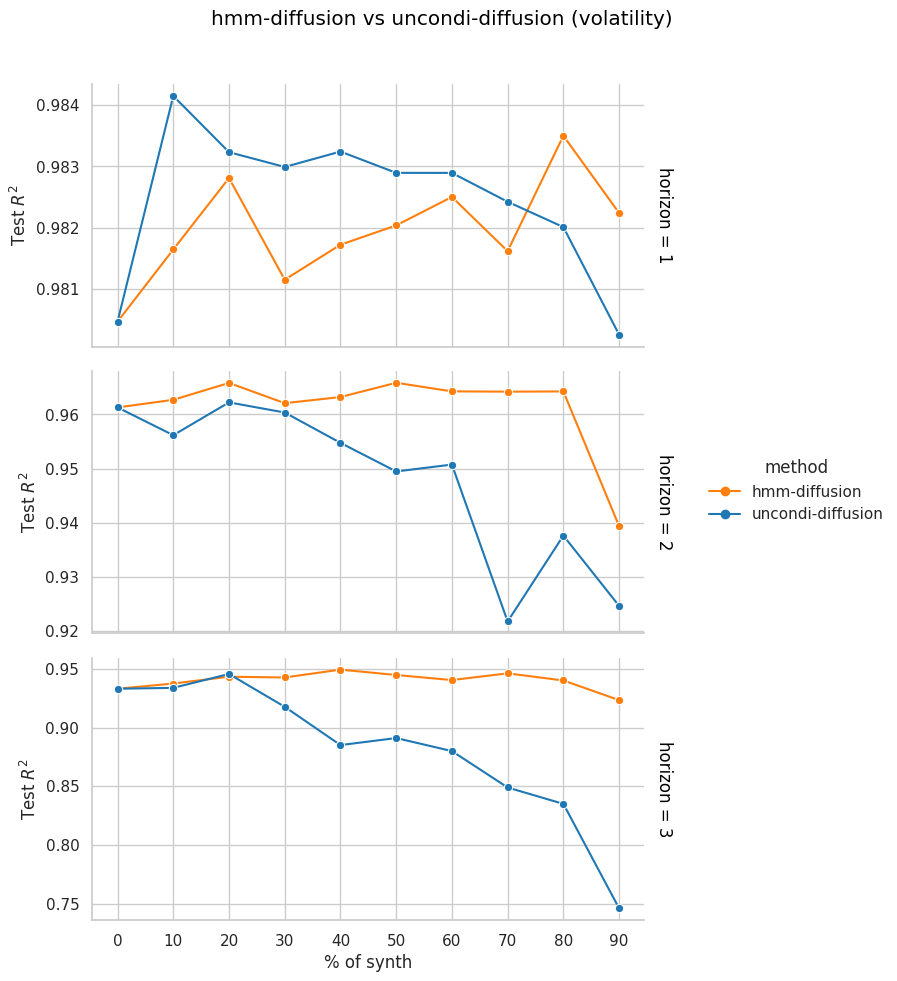

In [14]:
plots.plot_vol_mixture_column(
    all_metrics,
    all_metrics_uncond,
    horizons=HORIZONS,
    title="hmm-diffusion vs uncondi-diffusion (volatility)",
    save_path=PLOT_ROOT / "vol_mixture_grid.eps",
)